In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B
from qiskit_algorithms.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit

In [20]:
# Load the dataset from CSV
df = pd.read_csv('C:/Users/IITIEE/Desktop/SOUMEN DAS/Data_set/USA_Housing.csv')
print(df.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [21]:
df.drop(['Address'], axis = 1 ,inplace=True)
print(df)

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population         Price  
0                             4.09     2308

In [22]:
from sklearn.preprocessing import MinMaxScaler
print(df)
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df.to_numpy())
df_scaled = pd.DataFrame(df_scaled, columns=[
  'Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms','Area Population','Price'])
 
print("Scaled Dataset Using MinMaxScaler")
df_scaled.head()

features = MinMaxScaler().fit_transform(df_scaled)
print(features)

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population         Price  
0                             4.09     2308

In [23]:
mean=df_scaled["Price"].mean()
print("mean of price \n",mean)

mean of price 
 0.4957484988842136


In [24]:
cutoff =mean                            # Decide on a cutoff limit
print(cutoff)
df_scaled['Buys House(class Label)'] = [0 if x > cutoff else 1 for x in df_scaled['Price']]
print(df_scaled)

0.4957484988842136
      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0             0.686822             0.441986                   0.501502   
1             0.683521             0.488538                   0.464501   
2             0.483737             0.468609                   0.701350   
3             0.506630             0.660956                   0.312430   
4             0.469223             0.348556                   0.611851   
...                ...                  ...                        ...   
4995          0.475738             0.754359                   0.385619   
4996          0.675097             0.633450                   0.444024   
4997          0.507135             0.670026                   0.208534   
4998          0.558419             0.420389                   0.517579   
4999          0.530715             0.486997                   0.472678   

      Avg. Area Number of Bedrooms  Area Population     Price  \
0                         0

In [25]:
X = df_scaled[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population','Price']]
print(X)
y = df_scaled['Buys House(class Label)']
print(y)

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0             0.686822             0.441986                   0.501502   
1             0.683521             0.488538                   0.464501   
2             0.483737             0.468609                   0.701350   
3             0.506630             0.660956                   0.312430   
4             0.469223             0.348556                   0.611851   
...                ...                  ...                        ...   
4995          0.475738             0.754359                   0.385619   
4996          0.675097             0.633450                   0.444024   
4997          0.507135             0.670026                   0.208534   
4998          0.558419             0.420389                   0.517579   
4999          0.530715             0.486997                   0.472678   

      Avg. Area Number of Bedrooms  Area Population     Price  
0                         0.464444         0.32

In [26]:
#print(X) 
print("type X=",type(X))
X = X.to_numpy()
print("features=",X)
print("type X=",type(X))
print("features=",X)
#print(y)
print("type y=",type(y))
y = y.to_numpy()
print("Class labels = ",y)
print("type y=",type(y))

type X= <class 'pandas.core.frame.DataFrame'>
features= [[0.68682217 0.44198584 0.50150158 0.46444444 0.3299422  0.42521032]
 [0.68352073 0.48853836 0.46450137 0.24222222 0.57596801 0.60736859]
 [0.48373705 0.46860901 0.70135011 0.69555556 0.52858204 0.42519175]
 ...
 [0.50713527 0.67002636 0.20853446 0.02888889 0.47651494 0.41367241]
 [0.55841872 0.4203891  0.51757886 0.76444444 0.61128233 0.48212679]
 [0.53071451 0.48699729 0.47267788 0.46       0.66708815 0.52301078]]
type X= <class 'numpy.ndarray'>
features= [[0.68682217 0.44198584 0.50150158 0.46444444 0.3299422  0.42521032]
 [0.68352073 0.48853836 0.46450137 0.24222222 0.57596801 0.60736859]
 [0.48373705 0.46860901 0.70135011 0.69555556 0.52858204 0.42519175]
 ...
 [0.50713527 0.67002636 0.20853446 0.02888889 0.47651494 0.41367241]
 [0.55841872 0.4203891  0.51757886 0.76444444 0.61128233 0.48212679]
 [0.53071451 0.48699729 0.47267788 0.46       0.66708815 0.52301078]]
type y= <class 'pandas.core.series.Series'>
Class labels =  [1

features= [[0.68682217 0.44198584 0.50150158 0.46444444 0.3299422  0.42521032]
 [0.68352073 0.48853836 0.46450137 0.24222222 0.57596801 0.60736859]
 [0.48373705 0.46860901 0.70135011 0.69555556 0.52858204 0.42519175]
 ...
 [0.50713527 0.67002636 0.20853446 0.02888889 0.47651494 0.41367241]
 [0.55841872 0.4203891  0.51757886 0.76444444 0.61128233 0.48212679]
 [0.53071451 0.48699729 0.47267788 0.46       0.66708815 0.52301078]]
type X= <class 'numpy.ndarray'>
mean values of each features =
 [1. 1. 1. 1. 1. 1.]
No of features max =
 6
Class labels =  [1 0 1 ... 1 1 0]
type y= <class 'numpy.ndarray'>


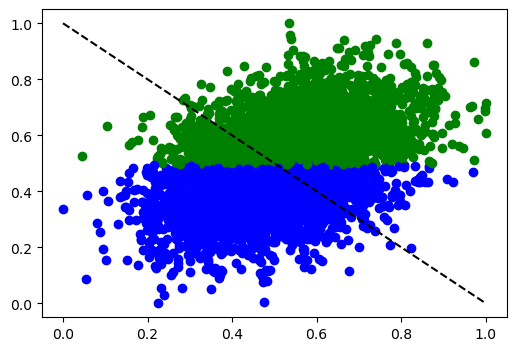

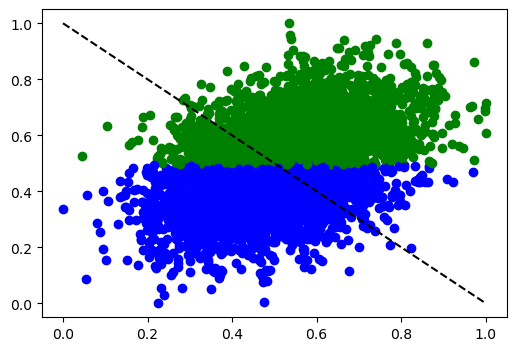

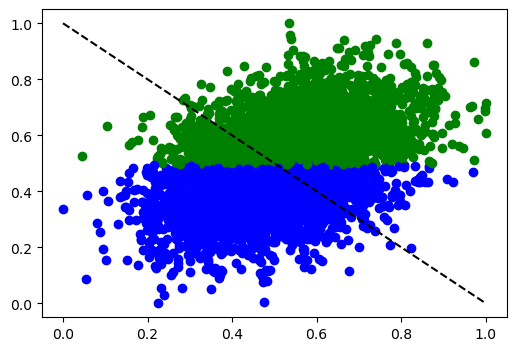

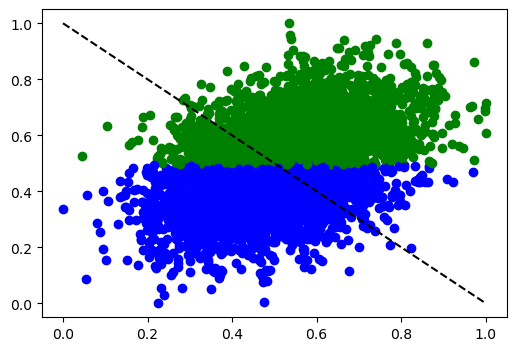

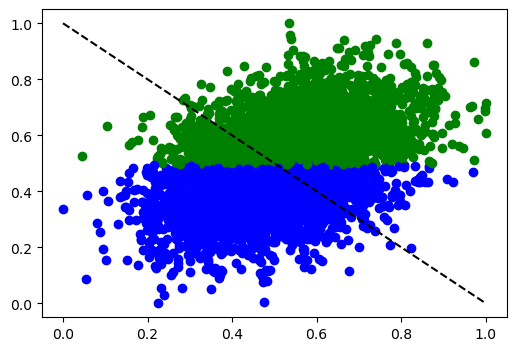

In [27]:
print("features=",X)
print("type X=",type(X))
No_features=X.max(axis=0)
threshold=No_features.max(axis=0)

print("mean values of each features =\n",No_features)
print("No of features max =\n",len(No_features))

#y = y.to_numpy()
print("Class labels = ",y)
print("type y=",type(y))
for i in range(0,len(No_features)-1):
    #threshold=temp[i]
    for x, y_target in zip(X, y):
        if y_target == 1:
            plt.plot(x[0], x[1],x[2],x[3],x[4],x[5], "bo")
            #print(x[0], x[1])
        elif y_target == 0:
            plt.plot(x[0], x[1],x[2],x[3],x[4],x[5], "go")
            #print(x[0], x[1])
        else:
            print("Not a Binary Classifier")
    plt.plot([0, threshold], [threshold, 0], "--", color="black")
    plt.show()

C:\Users\IITIEE\AppData\Roaming\Python\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


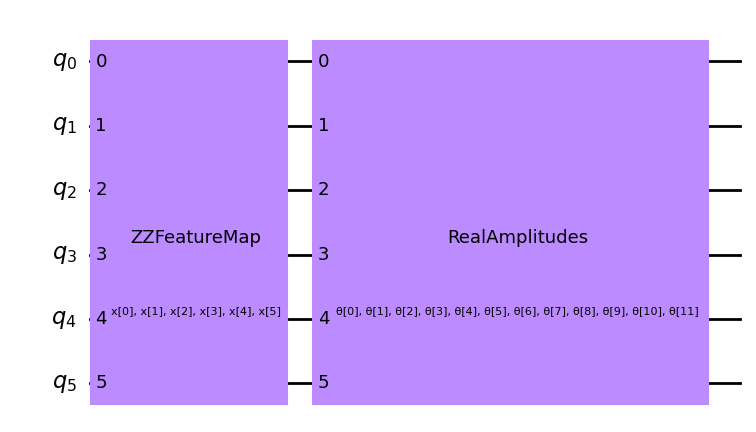

In [28]:
# construct a quantum circuit from the default ZZFeatureMap feature map and a customized RealAmplitudes ansatz
qc = QNNCircuit(ansatz=RealAmplitudes(len(No_features), reps=1))  # len(X) == No of features= No of qubits
qc.draw(output="mpl")

In [29]:
# parity maps bitstrings to 0 or 1
def parity(x):
    temp="{:b}".format(x).count("1") % 2
    #print(temp)
    return temp
output_shape = 2  # corresponds to the number of classes and possible outcomes of the (parity) mapping.

In [30]:
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [31]:
# construct QNN
sampler_qnn = SamplerQNN(
    circuit=qc,
    interpret=parity,
    output_shape=output_shape,
)

In [32]:
Num_iter=int(input("Please Enter the iteration Number="))

Please Enter the iteration Number= 200


In [33]:
# construct classifier
sampler_classifier = NeuralNetworkClassifier(
    neural_network=sampler_qnn, optimizer=COBYLA(maxiter=Num_iter), callback=callback_graph
)

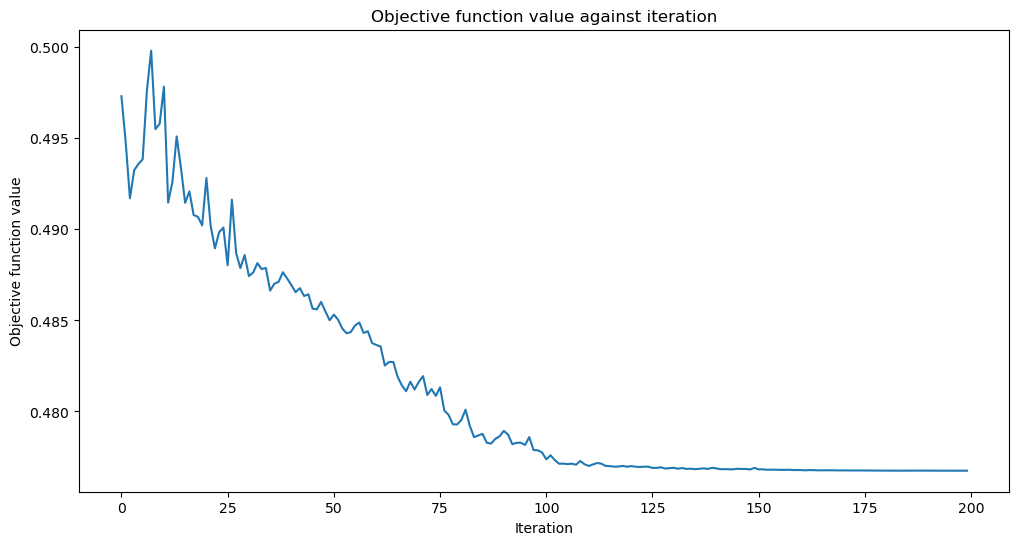

Training time: 132764 seconds
classifier score = 0.6268


In [34]:
import time

# Create an empty array for a callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

start = time.time()
# fit classifier to data
sampler_classifier.fit(X, y)
elapsed = time.time() - start
print(f"Training time: {round(elapsed)} seconds")

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score classifier
classifier_score=sampler_classifier.score(X, y)
print("classifier score =",classifier_score)

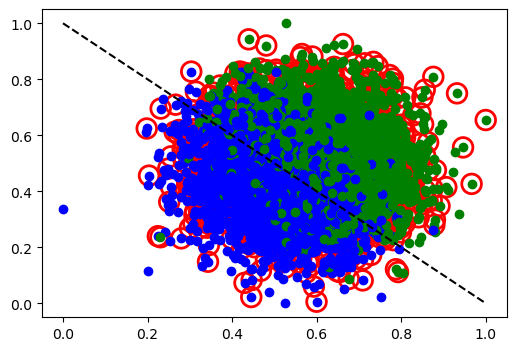

In [35]:
# evaluate data points
y_predict = sampler_classifier.predict(X)

# plot results
# red == wrongly classified
for x, y_target, y_p in zip(X, y, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([0, threshold], [threshold, 0], "--", color="black")
plt.show()

In [36]:
sampler_classifier.weights

array([ 0.67973809,  2.15173378,  1.91328217,  1.93290619,  0.35859476,
       -0.72201453,  0.91426453,  0.79415849,  0.25633086, -0.15851551,
        1.37972161,  1.56897523])